# Module 5 (Week 5): Analysis of Variance (ANOVA)

**Week 5:** Module 5 - Comparing Multiple Groups Simultaneously

**Topics Covered:**
- Introduction to Experimental Design & ANOVA
- One-Way ANOVA: Theory and Implementation
- Between-Group vs Within-Group Variance
- F-Statistic Calculation and ANOVA Table
- Post-hoc Testing with Tukey's HSD
- Assumptions and Diagnostics
- Real-World Applications

---

## Module Introduction

In Weeks 3 and 4, we learned how to compare one or two groups. But what if we have **three or more groups** to compare?

**The Problem with Multiple t-tests:**
If we have 4 groups and want to compare all pairs:
- Number of comparisons = C(4,2) = 6 t-tests
- With α = 0.05 for each test
- Probability of at least one Type I error = 1 - (0.95)^6 ≈ 0.26 (26%!)

This is called the **multiple comparisons problem**. ANOVA solves this elegantly!

### Learning Objectives:

By the end of this module, you will be able to:

1. **Understand the logic** behind Analysis of Variance
2. **Decompose total variance** into between-group and within-group components
3. **Conduct one-way ANOVA** tests properly
4. **Interpret ANOVA tables** and F-statistics
5. **Perform post-hoc tests** to identify which groups differ
6. **Check assumptions** and know when ANOVA is appropriate

### Why ANOVA Matters:

ANOVA is fundamental in:
- **Clinical Trials:** Comparing multiple treatments
- **Quality Control:** Testing multiple production lines
- **Education:** Comparing teaching methods across schools
- **Marketing:** A/B/C/D testing
- **Agriculture:** Comparing crop yields with different fertilizers

---

In [ ]:
# Setup: Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.multicomp import MultiComparison
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("Setup Complete! All libraries loaded successfully.")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print("-" * 60)
print("Ready for ANOVA analysis!")

Setup Complete! All libraries loaded successfully.
NumPy version: 2.0.2
Pandas version: 2.2.2
------------------------------------------------------------
Ready for ANOVA analysis!


---

## Section 1: Introduction to Experimental Design & ANOVA Concepts

### What is ANOVA?

**ANOVA (Analysis of Variance)** is a statistical method that tests whether the means of three or more groups are equal. Despite its name focusing on "variance," ANOVA actually tests differences in **means**!

### The Genius of ANOVA: Using Variance to Test Means

ANOVA's key insight: If groups have different means, the **variance between groups** will be large relative to the **variance within groups**.

Think of it this way:
- **Between-group variance:** How much do group means differ from each other?
- **Within-group variance:** How much do individual observations vary within each group?

If the ratio (Between/Within) is large → Groups are likely different!

### The Fundamental ANOVA Equation

$$\text{Total Variance} = \text{Between-Group Variance} + \text{Within-Group Variance}$$

Or in terms of Sum of Squares (SS):
$$SS_{Total} = SS_{Between} + SS_{Within}$$

### Visual Intuition

Let's visualize this concept with three scenarios:

---

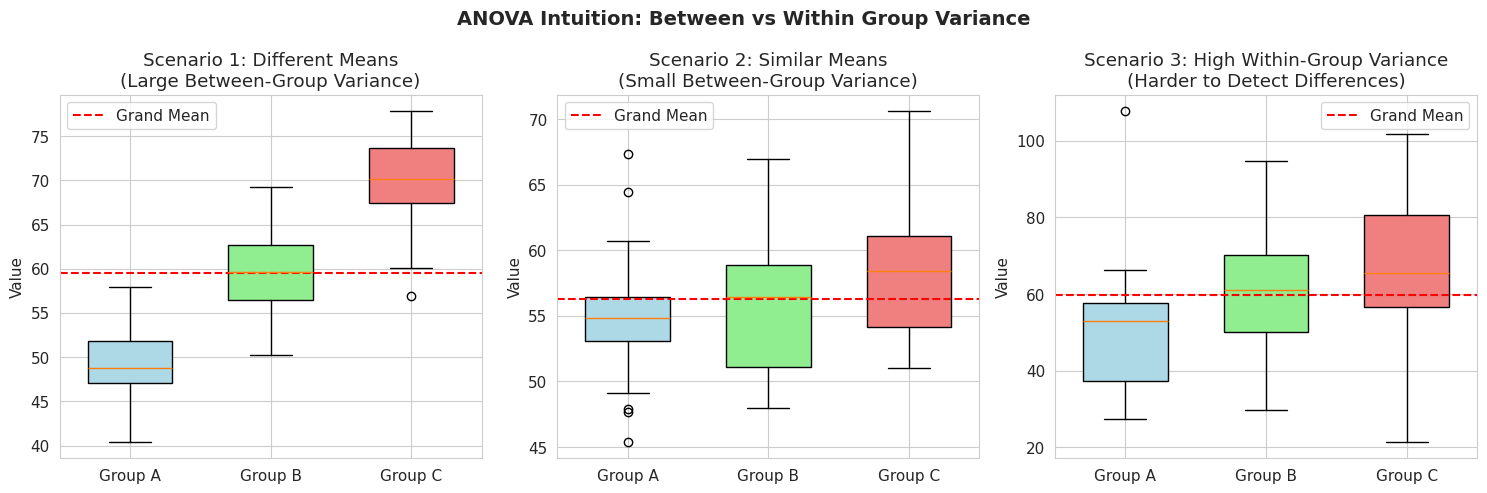

F-Statistics for Each Scenario:
Scenario 1 (Different means): F = 149.24, p-value = 0.0000
  Conclusion: Groups are significantly different

Scenario 2 (Similar means):   F = 4.51, p-value = 0.0137
  Conclusion: Groups are significantly different

Scenario 3 (High variance):   F = 8.13, p-value = 0.0006
  Conclusion: Groups are significantly different


In [ ]:
# Visualizing ANOVA Concepts: Three Scenarios

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Scenario 1: Groups are different (ANOVA will detect)
np.random.seed(42)
group1_different = np.random.normal(50, 5, 30)
group2_different = np.random.normal(60, 5, 30)
group3_different = np.random.normal(70, 5, 30)

ax1 = axes[0]
positions = [1, 2, 3]
bp1 = ax1.boxplot([group1_different, group2_different, group3_different],
                   positions=positions, widths=0.6, patch_artist=True)
for patch, color in zip(bp1['boxes'], ['lightblue', 'lightgreen', 'lightcoral']):
    patch.set_facecolor(color)
ax1.set_xticklabels(['Group A', 'Group B', 'Group C'])
ax1.set_ylabel('Value')
ax1.set_title('Scenario 1: Different Means\n(Large Between-Group Variance)')
ax1.axhline(np.mean(np.concatenate([group1_different, group2_different, group3_different])),
            color='red', linestyle='--', label='Grand Mean')
ax1.legend()

# Scenario 2: Groups are similar (ANOVA won't detect)
group1_similar = np.random.normal(55, 5, 30)
group2_similar = np.random.normal(56, 5, 30)
group3_similar = np.random.normal(57, 5, 30)

ax2 = axes[1]
bp2 = ax2.boxplot([group1_similar, group2_similar, group3_similar],
                   positions=positions, widths=0.6, patch_artist=True)
for patch, color in zip(bp2['boxes'], ['lightblue', 'lightgreen', 'lightcoral']):
    patch.set_facecolor(color)
ax2.set_xticklabels(['Group A', 'Group B', 'Group C'])
ax2.set_ylabel('Value')
ax2.set_title('Scenario 2: Similar Means\n(Small Between-Group Variance)')
ax2.axhline(np.mean(np.concatenate([group1_similar, group2_similar, group3_similar])),
            color='red', linestyle='--', label='Grand Mean')
ax2.legend()

# Scenario 3: High within-group variance
group1_high_var = np.random.normal(50, 15, 30)
group2_high_var = np.random.normal(60, 15, 30)
group3_high_var = np.random.normal(70, 15, 30)

ax3 = axes[2]
bp3 = ax3.boxplot([group1_high_var, group2_high_var, group3_high_var],
                   positions=positions, widths=0.6, patch_artist=True)
for patch, color in zip(bp3['boxes'], ['lightblue', 'lightgreen', 'lightcoral']):
    patch.set_facecolor(color)
ax3.set_xticklabels(['Group A', 'Group B', 'Group C'])
ax3.set_ylabel('Value')
ax3.set_title('Scenario 3: High Within-Group Variance\n(Harder to Detect Differences)')
ax3.axhline(np.mean(np.concatenate([group1_high_var, group2_high_var, group3_high_var])),
            color='red', linestyle='--', label='Grand Mean')
ax3.legend()

plt.suptitle('ANOVA Intuition: Between vs Within Group Variance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Calculate and display F-statistics for each scenario
print("F-Statistics for Each Scenario:")
print("=" * 60)
f_stat1, p_val1 = stats.f_oneway(group1_different, group2_different, group3_different)
print(f"Scenario 1 (Different means): F = {f_stat1:.2f}, p-value = {p_val1:.4f}")
print(f"  Conclusion: {'Groups are significantly different' if p_val1 < 0.05 else 'No significant difference'}")
print()

f_stat2, p_val2 = stats.f_oneway(group1_similar, group2_similar, group3_similar)
print(f"Scenario 2 (Similar means):   F = {f_stat2:.2f}, p-value = {p_val2:.4f}")
print(f"  Conclusion: {'Groups are significantly different' if p_val2 < 0.05 else 'No significant difference'}")
print()

f_stat3, p_val3 = stats.f_oneway(group1_high_var, group2_high_var, group3_high_var)
print(f"Scenario 3 (High variance):   F = {f_stat3:.2f}, p-value = {p_val3:.4f}")
print(f"  Conclusion: {'Groups are significantly different' if p_val3 < 0.05 else 'No significant difference'}")
print("=" * 60)

---

## Section 2: One-Way ANOVA - The Mathematics

### Hypotheses in ANOVA

**Null Hypothesis (H₀):** All group means are equal
$$H_0: \mu_1 = \mu_2 = \mu_3 = ... = \mu_k$$

**Alternative Hypothesis (H₁):** At least one group mean is different
$$H_1: \text{At least one } \mu_i \neq \mu_j$$

### Key Components

1. **Grand Mean (GM):** Overall mean of all observations
2. **Group Means:** Mean of each individual group
3. **Total Sum of Squares (SST):** Total variation in the data
4. **Between-Group Sum of Squares (SSB):** Variation due to differences between groups
5. **Within-Group Sum of Squares (SSW):** Variation within groups (error)

### The F-Statistic

$$F = \frac{\text{Mean Square Between}}{\text{Mean Square Within}} = \frac{MSB}{MSW}$$

Where:
- $MSB = \frac{SSB}{df_{between}} = \frac{SSB}{k-1}$
- $MSW = \frac{SSW}{df_{within}} = \frac{SSW}{N-k}$
- $k$ = number of groups
- $N$ = total number of observations

### Manual Calculation Example

Let's manually calculate ANOVA to understand the mechanics:

---

In [ ]:
# Manual ANOVA Calculation - Step by Step

print("=" * 80)
print("MANUAL ONE-WAY ANOVA CALCULATION")
print("=" * 80)
print()

# Create sample data for 3 groups
np.random.seed(42)
group_A = np.array([23, 25, 27, 22, 26, 24, 25, 28, 26, 24])
group_B = np.array([31, 33, 35, 30, 34, 32, 33, 36, 34, 32])
group_C = np.array([38, 40, 42, 37, 41, 39, 40, 43, 41, 39])

# Combine all data
all_data = np.concatenate([group_A, group_B, group_C])
n_A, n_B, n_C = len(group_A), len(group_B), len(group_C)
N = len(all_data)
k = 3  # number of groups

print("DATA:")
print(f"  Group A (n={n_A}): {group_A}")
print(f"  Group B (n={n_B}): {group_B}")
print(f"  Group C (n={n_C}): {group_C}")
print()

# Step 1: Calculate means
mean_A = np.mean(group_A)
mean_B = np.mean(group_B)
mean_C = np.mean(group_C)
grand_mean = np.mean(all_data)

print("STEP 1: Calculate Means")
print("-" * 80)
print(f"  Group A mean: {mean_A:.2f}")
print(f"  Group B mean: {mean_B:.2f}")
print(f"  Group C mean: {mean_C:.2f}")
print(f"  Grand mean: {grand_mean:.2f}")
print()

# Step 2: Calculate Sum of Squares
# Total Sum of Squares (SST)
SST = np.sum((all_data - grand_mean)**2)

# Between-Group Sum of Squares (SSB)
SSB = n_A * (mean_A - grand_mean)**2 +       n_B * (mean_B - grand_mean)**2 +       n_C * (mean_C - grand_mean)**2

# Within-Group Sum of Squares (SSW)
SSW_A = np.sum((group_A - mean_A)**2)
SSW_B = np.sum((group_B - mean_B)**2)
SSW_C = np.sum((group_C - mean_C)**2)
SSW = SSW_A + SSW_B + SSW_C

print("STEP 2: Calculate Sum of Squares")
print("-" * 80)
print(f"  Total SS (SST): {SST:.2f}")
print(f"  Between-Group SS (SSB): {SSB:.2f}")
print(f"  Within-Group SS (SSW): {SSW:.2f}")
print(f"  Verification: SST = SSB + SSW → {SST:.2f} = {SSB + SSW:.2f} ✓")
print()

# Step 3: Calculate Degrees of Freedom
df_between = k - 1
df_within = N - k
df_total = N - 1

print("STEP 3: Calculate Degrees of Freedom")
print("-" * 80)
print(f"  df_between: k - 1 = {k} - 1 = {df_between}")
print(f"  df_within: N - k = {N} - {k} = {df_within}")
print(f"  df_total: N - 1 = {N} - 1 = {df_total}")
print()

# Step 4: Calculate Mean Squares
MSB = SSB / df_between
MSW = SSW / df_within

print("STEP 4: Calculate Mean Squares")
print("-" * 80)
print(f"  Mean Square Between (MSB): SSB/df_between = {SSB:.2f}/{df_between} = {MSB:.2f}")
print(f"  Mean Square Within (MSW): SSW/df_within = {SSW:.2f}/{df_within} = {MSW:.2f}")
print()

# Step 5: Calculate F-statistic
F_stat = MSB / MSW

print("STEP 5: Calculate F-statistic")
print("-" * 80)
print(f"  F = MSB/MSW = {MSB:.2f}/{MSW:.2f} = {F_stat:.2f}")
print()

# Step 6: Find p-value
p_value = 1 - stats.f.cdf(F_stat, df_between, df_within)

print("STEP 6: Find p-value")
print("-" * 80)
print(f"  p-value = {p_value:.6f}")
print()

# Step 7: Make decision
alpha = 0.05
print("STEP 7: Make Decision (α = 0.05)")
print("-" * 80)
if p_value < alpha:
    print(f"  p-value ({p_value:.6f}) < α ({alpha})")
    print("  Decision: REJECT H₀")
    print("  Conclusion: At least one group mean is significantly different!")
else:
    print(f"  p-value ({p_value:.6f}) ≥ α ({alpha})")
    print("  Decision: FAIL TO REJECT H₀")
    print("  Conclusion: No significant difference between group means")

print("=" * 80)

MANUAL ONE-WAY ANOVA CALCULATION

DATA:
  Group A (n=10): [23 25 27 22 26 24 25 28 26 24]
  Group B (n=10): [31 33 35 30 34 32 33 36 34 32]
  Group C (n=10): [38 40 42 37 41 39 40 43 41 39]

STEP 1: Calculate Means
--------------------------------------------------------------------------------
  Group A mean: 25.00
  Group B mean: 33.00
  Group C mean: 40.00
  Grand mean: 32.67

STEP 2: Calculate Sum of Squares
--------------------------------------------------------------------------------
  Total SS (SST): 1216.67
  Between-Group SS (SSB): 1126.67
  Within-Group SS (SSW): 90.00
  Verification: SST = SSB + SSW → 1216.67 = 1216.67 ✓

STEP 3: Calculate Degrees of Freedom
--------------------------------------------------------------------------------
  df_between: k - 1 = 3 - 1 = 2
  df_within: N - k = 30 - 3 = 27
  df_total: N - 1 = 30 - 1 = 29

STEP 4: Calculate Mean Squares
--------------------------------------------------------------------------------
  Mean Square Between (MSB): 

In [ ]:
# ANOVA Table Construction

print("=" * 80)
print("ANOVA TABLE")
print("=" * 80)
print()

# Create ANOVA table
anova_table = pd.DataFrame({
    'Source': ['Between Groups', 'Within Groups', 'Total'],
    'SS': [SSB, SSW, SST],
    'df': [df_between, df_within, df_total],
    'MS': [MSB, MSW, ''],
    'F': [F_stat, '', ''],
    'p-value': [f'{p_value:.6f}', '', '']
})

# Display table with formatting
print(anova_table.to_string(index=False))
print()

# Verify using scipy
f_scipy, p_scipy = stats.f_oneway(group_A, group_B, group_C)
print("-" * 80)
print("VERIFICATION using scipy.stats.f_oneway:")
print(f"  F-statistic: {f_scipy:.2f}")
print(f"  p-value: {p_scipy:.6f}")
print("  Results match our manual calculation! ✓")
print("=" * 80)

ANOVA TABLE

        Source          SS  df          MS      F  p-value
Between Groups 1126.666667   2  563.333333  169.0 0.000000
 Within Groups   90.000000  27    3.333333                
         Total 1216.666667  29                            

--------------------------------------------------------------------------------
VERIFICATION using scipy.stats.f_oneway:
  F-statistic: 169.00
  p-value: 0.000000
  Results match our manual calculation! ✓


---

## Section 3: Visualizing ANOVA Components

Let's create visualizations to understand how variance is decomposed in ANOVA:

---

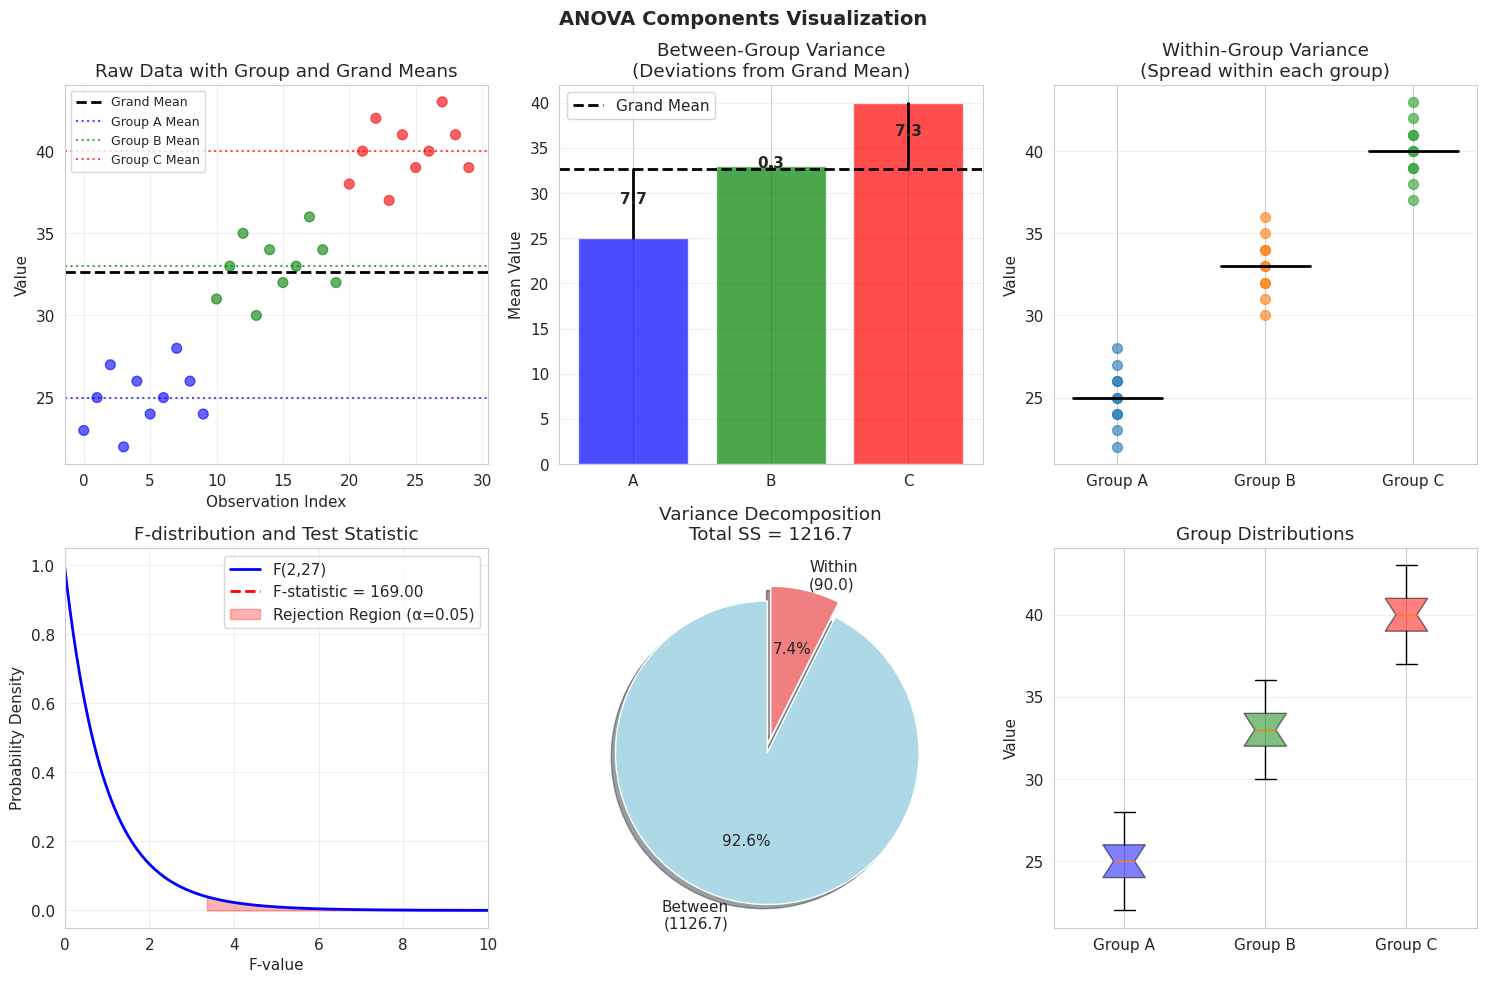

In [ ]:
# Comprehensive ANOVA Visualization

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Raw Data with Means
ax1 = axes[0, 0]
groups = ['A'] * n_A + ['B'] * n_B + ['C'] * n_C
values = list(group_A) + list(group_B) + list(group_C)
colors = ['blue'] * n_A + ['green'] * n_B + ['red'] * n_C

ax1.scatter(range(len(values)), values, c=colors, alpha=0.6, s=50)
ax1.axhline(grand_mean, color='black', linestyle='--', linewidth=2, label='Grand Mean')
ax1.axhline(mean_A, color='blue', linestyle=':', alpha=0.7, label='Group A Mean')
ax1.axhline(mean_B, color='green', linestyle=':', alpha=0.7, label='Group B Mean')
ax1.axhline(mean_C, color='red', linestyle=':', alpha=0.7, label='Group C Mean')
ax1.set_xlabel('Observation Index')
ax1.set_ylabel('Value')
ax1.set_title('Raw Data with Group and Grand Means')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# 2. Between-Group Variance
ax2 = axes[0, 1]
group_means = [mean_A, mean_B, mean_C]
group_names = ['A', 'B', 'C']
bars = ax2.bar(group_names, group_means, color=['blue', 'green', 'red'], alpha=0.7)
ax2.axhline(grand_mean, color='black', linestyle='--', linewidth=2, label='Grand Mean')

# Add error bars showing deviation from grand mean
for i, (mean, bar) in enumerate(zip(group_means, bars)):
    ax2.plot([i, i], [grand_mean, mean], 'k-', linewidth=2)
    ax2.text(i, (grand_mean + mean)/2, f'{abs(mean-grand_mean):.1f}',
             ha='center', fontweight='bold')

ax2.set_ylabel('Mean Value')
ax2.set_title('Between-Group Variance\n(Deviations from Grand Mean)')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# 3. Within-Group Variance
ax3 = axes[0, 2]
positions = []
for i, (group_data, mean) in enumerate([(group_A, mean_A),
                                         (group_B, mean_B),
                                         (group_C, mean_C)]):
    x_pos = np.ones(len(group_data)) * i
    ax3.scatter(x_pos, group_data, alpha=0.6, s=50)
    ax3.plot([i-0.3, i+0.3], [mean, mean], 'k-', linewidth=2)

ax3.set_xticks([0, 1, 2])
ax3.set_xticklabels(['Group A', 'Group B', 'Group C'])
ax3.set_ylabel('Value')
ax3.set_title('Within-Group Variance\n(Spread within each group)')
ax3.grid(True, alpha=0.3, axis='y')

# 4. F-distribution with test statistic
ax4 = axes[1, 0]
x = np.linspace(0, 10, 1000)
y = stats.f.pdf(x, df_between, df_within)
ax4.plot(x, y, 'b-', linewidth=2, label=f'F({df_between},{df_within})')
ax4.axvline(F_stat, color='red', linestyle='--', linewidth=2,
            label=f'F-statistic = {F_stat:.2f}')

# Shade rejection region
alpha = 0.05
f_crit = stats.f.ppf(1 - alpha, df_between, df_within)
x_reject = x[x >= f_crit]
y_reject = stats.f.pdf(x_reject, df_between, df_within)
ax4.fill_between(x_reject, y_reject, alpha=0.3, color='red',
                  label=f'Rejection Region (α={alpha})')

ax4.set_xlabel('F-value')
ax4.set_ylabel('Probability Density')
ax4.set_title('F-distribution and Test Statistic')
ax4.legend()
ax4.grid(True, alpha=0.3)
ax4.set_xlim(0, 10)

# 5. Variance Decomposition Pie Chart
ax5 = axes[1, 1]
sizes = [SSB, SSW]
labels = [f'Between\n({SSB:.1f})', f'Within\n({SSW:.1f})']
colors = ['lightblue', 'lightcoral']
explode = (0.1, 0)
ax5.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=90)
ax5.set_title(f'Variance Decomposition\nTotal SS = {SST:.1f}')

# 6. Group Comparison Box Plots
ax6 = axes[1, 2]
bp = ax6.boxplot([group_A, group_B, group_C], labels=['Group A', 'Group B', 'Group C'],
                  patch_artist=True, notch=True)
for patch, color in zip(bp['boxes'], ['blue', 'green', 'red']):
    patch.set_facecolor(color)
    patch.set_alpha(0.5)
ax6.set_ylabel('Value')
ax6.set_title('Group Distributions')
ax6.grid(True, alpha=0.3, axis='y')

plt.suptitle('ANOVA Components Visualization', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

## Section 4: Real-World Example - Comparing Drug Efficacy

Let's apply ANOVA to a realistic scenario: comparing the effectiveness of four different treatments for reducing blood pressure.

---

In [ ]:
# Real-World ANOVA Example: Drug Efficacy Study

print("=" * 80)
print("CLINICAL TRIAL: Comparing Four Blood Pressure Medications")
print("=" * 80)
print()

# Generate realistic data for 4 treatment groups
np.random.seed(42)

# Baseline BP reduction for each drug (mm Hg)
placebo = np.random.normal(5, 4, 25)      # Minimal effect
drug_a = np.random.normal(12, 3.5, 28)    # Moderate effect
drug_b = np.random.normal(15, 3, 26)      # Good effect
drug_c = np.random.normal(18, 4, 27)      # Best effect

# Ensure positive values (BP reduction)
placebo = np.abs(placebo)
drug_a = np.abs(drug_a)
drug_b = np.abs(drug_b)
drug_c = np.abs(drug_c)

# Create DataFrame for easier manipulation
df = pd.DataFrame({
    'Reduction': np.concatenate([placebo, drug_a, drug_b, drug_c]),
    'Treatment': ['Placebo']*len(placebo) + ['Drug A']*len(drug_a) +
                 ['Drug B']*len(drug_b) + ['Drug C']*len(drug_c)
})

# Display summary statistics
summary = df.groupby('Treatment')['Reduction'].agg(['count', 'mean', 'std'])
print("SUMMARY STATISTICS:")
print("-" * 80)
print(summary)
print()

# Perform ANOVA
groups = [placebo, drug_a, drug_b, drug_c]
f_stat, p_value = stats.f_oneway(*groups)

print("ONE-WAY ANOVA RESULTS:")
print("-" * 80)
print("Hypotheses:")
print("  H₀: All treatments have equal mean BP reduction")
print("  H₁: At least one treatment differs in effectiveness")
print()
print(f"F-statistic: {f_stat:.3f}")
print(f"p-value: {p_value:.2e}")
print()

alpha = 0.05
if p_value < alpha:
    print(f"Decision: REJECT H₀ (p < {alpha})")
    print("Conclusion: Treatments have significantly different effects on BP!")
else:
    print(f"Decision: FAIL TO REJECT H₀ (p ≥ {alpha})")
    print("Conclusion: No significant difference between treatments")

# Calculate effect size (eta-squared)
grand_mean = df['Reduction'].mean()
ss_between = sum([len(group) * (np.mean(group) - grand_mean)**2 for group in groups])
ss_total = sum([(x - grand_mean)**2 for x in df['Reduction']])
eta_squared = ss_between / ss_total

print()
print(f"Effect Size (η²): {eta_squared:.3f}")
if eta_squared < 0.01:
    effect = "negligible"
elif eta_squared < 0.06:
    effect = "small"
elif eta_squared < 0.14:
    effect = "medium"
else:
    effect = "large"
print(f"Interpretation: {effect.upper()} effect")
print("=" * 80)

CLINICAL TRIAL: Comparing Four Blood Pressure Medications

SUMMARY STATISTICS:
--------------------------------------------------------------------------------
           count       mean       std
Treatment                            
Drug A        28  11.009511  3.093899
Drug B        26  15.472151  2.883062
Drug C        27  17.229148  3.054062
Placebo       25   4.818048  3.183315

ONE-WAY ANOVA RESULTS:
--------------------------------------------------------------------------------
Hypotheses:
  H₀: All treatments have equal mean BP reduction
  H₁: At least one treatment differs in effectiveness

F-statistic: 84.403
p-value: 1.59e-27

Decision: REJECT H₀ (p < 0.05)
Conclusion: Treatments have significantly different effects on BP!

Effect Size (η²): 0.713
Interpretation: LARGE effect


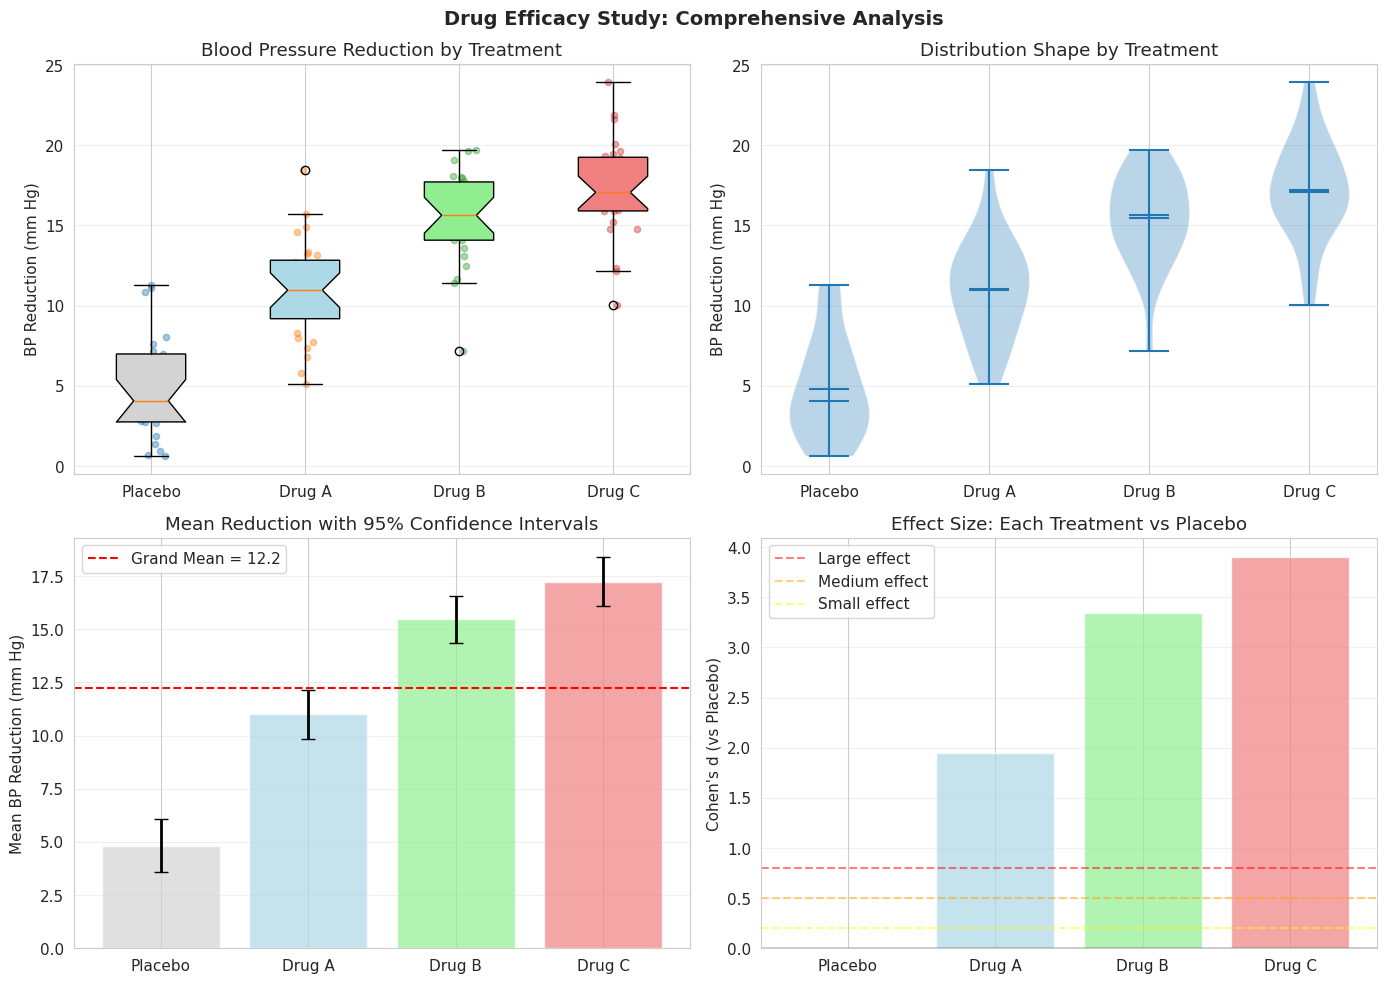

In [ ]:
# Visualization of Drug Efficacy Results

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Box plots with individual points
ax1 = axes[0, 0]
bp = ax1.boxplot([placebo, drug_a, drug_b, drug_c],
                  labels=['Placebo', 'Drug A', 'Drug B', 'Drug C'],
                  patch_artist=True, notch=True)

# Color the boxes
colors = ['lightgray', 'lightblue', 'lightgreen', 'lightcoral']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

# Add individual points
for i, group in enumerate(groups, 1):
    x = np.random.normal(i, 0.04, size=len(group))
    ax1.scatter(x, group, alpha=0.4, s=20)

ax1.set_ylabel('BP Reduction (mm Hg)')
ax1.set_title('Blood Pressure Reduction by Treatment')
ax1.grid(True, alpha=0.3, axis='y')

# 2. Violin plots
ax2 = axes[0, 1]
parts = ax2.violinplot([placebo, drug_a, drug_b, drug_c],
                        positions=[1, 2, 3, 4],
                        showmeans=True, showmedians=True)
ax2.set_xticks([1, 2, 3, 4])
ax2.set_xticklabels(['Placebo', 'Drug A', 'Drug B', 'Drug C'])
ax2.set_ylabel('BP Reduction (mm Hg)')
ax2.set_title('Distribution Shape by Treatment')
ax2.grid(True, alpha=0.3, axis='y')

# 3. Means with 95% CI
ax3 = axes[1, 0]
means = [np.mean(g) for g in groups]
stds = [np.std(g, ddof=1) for g in groups]
ns = [len(g) for g in groups]
ci_95 = [1.96 * s / np.sqrt(n) for s, n in zip(stds, ns)]

x_pos = np.arange(len(means))
ax3.bar(x_pos, means, yerr=ci_95, capsize=5, color=colors, alpha=0.7,
        error_kw={'linewidth': 2, 'ecolor': 'black'})
ax3.set_xticks(x_pos)
ax3.set_xticklabels(['Placebo', 'Drug A', 'Drug B', 'Drug C'])
ax3.set_ylabel('Mean BP Reduction (mm Hg)')
ax3.set_title('Mean Reduction with 95% Confidence Intervals')
ax3.axhline(grand_mean, color='red', linestyle='--',
            label=f'Grand Mean = {grand_mean:.1f}')
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# 4. Effect sizes comparison
ax4 = axes[1, 1]
# Calculate Cohen's d for each drug vs placebo
placebo_mean = np.mean(placebo)
placebo_std = np.std(placebo, ddof=1)
cohen_d = [(np.mean(g) - placebo_mean) / placebo_std for g in [placebo, drug_a, drug_b, drug_c]]
ax4.bar(['Placebo', 'Drug A', 'Drug B', 'Drug C'], cohen_d, color=colors, alpha=0.7)
ax4.set_ylabel("Cohen's d (vs Placebo)")
ax4.set_title('Effect Size: Each Treatment vs Placebo')
ax4.axhline(0, color='black', linestyle='-', linewidth=1)
ax4.axhline(0.8, color='red', linestyle='--', alpha=0.5, label='Large effect')
ax4.axhline(0.5, color='orange', linestyle='--', alpha=0.5, label='Medium effect')
ax4.axhline(0.2, color='yellow', linestyle='--', alpha=0.5, label='Small effect')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

plt.suptitle('Drug Efficacy Study: Comprehensive Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

## Section 5: Post-hoc Testing with Tukey's HSD

### The Need for Post-hoc Tests

ANOVA tells us that **at least one group is different**, but it doesn't tell us **which groups differ**. This is where post-hoc tests come in!

### Tukey's Honestly Significant Difference (HSD)

Tukey's HSD is the most common post-hoc test. It:
- Controls the family-wise error rate
- Compares all possible pairs of groups
- Provides confidence intervals for differences

The test statistic for comparing groups i and j:
$$q = \frac{|\bar{x}_i - \bar{x}_j|}{\sqrt{\frac{MSW}{n}}}$$

---

In [ ]:
# Tukey's HSD Post-hoc Analysis

print("=" * 80)
print("POST-HOC ANALYSIS: Tukey's HSD")
print("=" * 80)
print()
print("Since ANOVA showed significant differences, we need to identify")
print("which specific treatments differ from each other.")
print()

# Prepare data for Tukey's HSD
all_data = np.concatenate([placebo, drug_a, drug_b, drug_c])
labels = ['Placebo']*len(placebo) + ['Drug A']*len(drug_a) + \
         ['Drug B']*len(drug_b) + ['Drug C']*len(drug_c)

# Perform Tukey's HSD
mc = MultiComparison(all_data, labels)
tukey_result = mc.tukeyhsd(alpha=0.05)

# Display results
print(tukey_result)
print()

# Extract and format the results more clearly
print("PAIRWISE COMPARISONS:")
print("-" * 80)
print(f"{'Group 1':<10} {'Group 2':<10} {'Mean Diff':>10} {'Adjusted p':>12} {'Significant':>12}")
print("-" * 80)

# Get the results summary
summary = tukey_result.summary()
data = summary.data[1:]  # Skip header row

for row in data:
    group1, group2, meandiff, pval_adj = row[0], row[1], row[2], row[3]
    sig = "YES" if row[6] else "NO"  # NOW FIXED - row[6] contains the reject boolean
    print(f"{group1:<10} {group2:<10} {meandiff:>10.2f} {pval_adj:>12.4f} {sig:>12}")

print("=" * 80)

POST-HOC ANALYSIS: Tukey's HSD

Since ANOVA showed significant differences, we need to identify
which specific treatments differ from each other.

  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1  group2 meandiff p-adj   lower    upper   reject
-------------------------------------------------------
Drug A  Drug B   4.4626    0.0   2.2895   6.6358   True
Drug A  Drug C   6.2196    0.0   4.0674   8.3719   True
Drug A Placebo  -6.1915    0.0  -8.3871  -3.9959   True
Drug B  Drug C    1.757 0.1623  -0.4355   3.9495  False
Drug B Placebo -10.6541    0.0 -12.8892   -8.419   True
Drug C Placebo -12.4111    0.0 -14.6258 -10.1964   True
-------------------------------------------------------

PAIRWISE COMPARISONS:
--------------------------------------------------------------------------------
Group 1    Group 2     Mean Diff   Adjusted p  Significant
--------------------------------------------------------------------------------
Drug A     Drug B           4.46       0.0000    

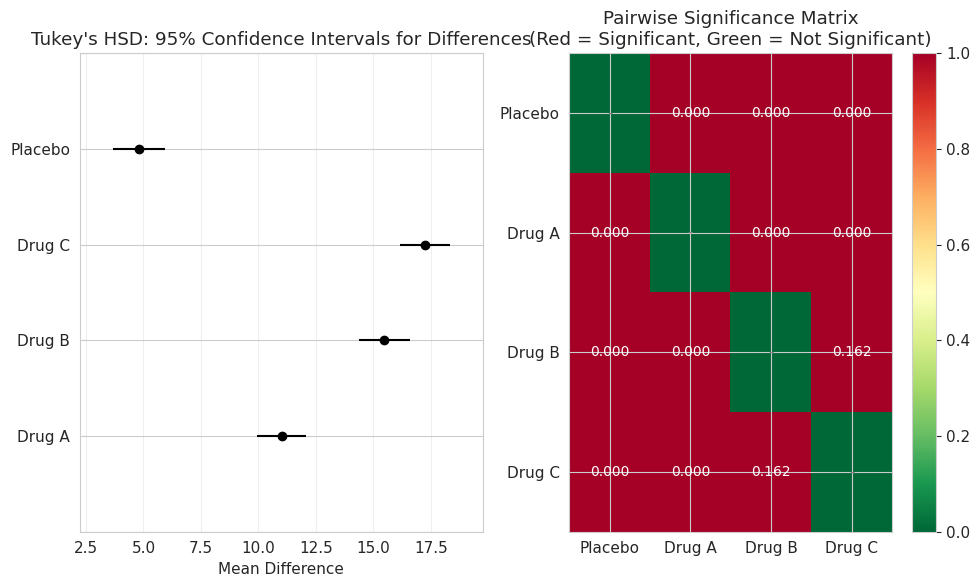

In [ ]:
# Visualize Tukey's HSD Results

# Create simultaneous confidence intervals plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Tukey HSD plot
ax1 = axes[0]
tukey_result.plot_simultaneous(ax=ax1)
ax1.set_title("Tukey's HSD: 95% Confidence Intervals for Differences")
ax1.set_xlabel('Mean Difference')
ax1.grid(True, alpha=0.3, axis='x')

# Plot 2: Custom pairwise comparison matrix
ax2 = axes[1]

# Create comparison matrix
treatments = ['Placebo', 'Drug A', 'Drug B', 'Drug C']
n_treatments = len(treatments)
comparison_matrix = np.zeros((n_treatments, n_treatments))
p_value_matrix = np.ones((n_treatments, n_treatments))

# Fill the matrix with p-values
for row in data:
    i = treatments.index(row[0])
    j = treatments.index(row[1])
    p_value_matrix[i, j] = row[3]
    p_value_matrix[j, i] = row[3]
    comparison_matrix[i, j] = 1 if row[5] else 0
    comparison_matrix[j, i] = 1 if row[5] else 0

# Create heatmap
im = ax2.imshow(comparison_matrix, cmap='RdYlGn_r', vmin=0, vmax=1, aspect='auto')
ax2.set_xticks(np.arange(n_treatments))
ax2.set_yticks(np.arange(n_treatments))
ax2.set_xticklabels(treatments)
ax2.set_yticklabels(treatments)
ax2.set_title('Pairwise Significance Matrix\n(Red = Significant, Green = Not Significant)')

# Add text annotations
for i in range(n_treatments):
    for j in range(n_treatments):
        if i != j:
            text = f'{p_value_matrix[i, j]:.3f}'
            color = 'white' if comparison_matrix[i, j] == 1 else 'black'
            ax2.text(j, i, text, ha="center", va="center", color=color, fontsize=10)
        else:
            ax2.text(j, i, '-', ha="center", va="center", color='gray')

plt.colorbar(im, ax=ax2)
plt.tight_layout()
plt.show()

---

## Section 6: ANOVA Assumptions and Diagnostics

### The Four Key Assumptions

ANOVA is robust, but it does make assumptions:

1. **Independence:** Observations are independent
2. **Normality:** Data within each group follows normal distribution
3. **Homogeneity of Variance:** All groups have equal variance (homoscedasticity)
4. **Random Sampling:** Data is randomly sampled from populations

### Checking Assumptions

Let's create diagnostic tools to check these assumptions:

---

In [ ]:
# ANOVA Assumptions Diagnostic Tests

def check_anova_assumptions(groups, group_names=None, alpha=0.05):
    '''
    Check ANOVA assumptions with diagnostic tests and plots
    '''
    if group_names is None:
        group_names = [f'Group {i+1}' for i in range(len(groups))]

    print("=" * 80)
    print("ANOVA ASSUMPTIONS DIAGNOSTIC")
    print("=" * 80)
    print()

    # 1. Normality Test (Shapiro-Wilk)
    print("1. NORMALITY TEST (Shapiro-Wilk)")
    print("-" * 80)
    normality_results = []
    for name, group in zip(group_names, groups):
        stat, p_val = stats.shapiro(group)
        normality_results.append(p_val > alpha)
        print(f"  {name}: W = {stat:.4f}, p = {p_val:.4f} ", end='')
        if p_val > alpha:
            print("✓ Normal")
        else:
            print("✗ Not Normal")
    print()

    # 2. Homogeneity of Variance (Levene's Test)
    print("2. HOMOGENEITY OF VARIANCE (Levene's Test)")
    print("-" * 80)
    stat, p_val = stats.levene(*groups)
    print(f"  Levene's statistic: {stat:.4f}")
    print(f"  p-value: {p_val:.4f}")
    if p_val > alpha:
        print(f"  Result: Variances are equal (p > {alpha}) ✓")
        variance_equal = True
    else:
        print(f"  Result: Variances are NOT equal (p < {alpha}) ✗")
        variance_equal = False
    print()

    # 3. Summary
    print("3. ASSUMPTION CHECK SUMMARY")
    print("-" * 80)
    all_normal = all(normality_results)

    if all_normal and variance_equal:
        print("  ✓ All assumptions are met - ANOVA is appropriate")
        recommendation = "Standard ANOVA"
    elif not all_normal:
        print("  ✗ Normality assumption violated")
        print("  Consider: Kruskal-Wallis test (non-parametric alternative)")
        recommendation = "Kruskal-Wallis"
    elif not variance_equal:
        print("  ✗ Equal variance assumption violated")
        print("  Consider: Welch's ANOVA or transformation")
        recommendation = "Welch's ANOVA"

    print("=" * 80)
    return recommendation

# Test assumptions on our drug data
print("Testing ANOVA assumptions for the drug efficacy study:")
recommendation = check_anova_assumptions([placebo, drug_a, drug_b, drug_c],
                                        ['Placebo', 'Drug A', 'Drug B', 'Drug C'])

Testing ANOVA assumptions for the drug efficacy study:
ANOVA ASSUMPTIONS DIAGNOSTIC

1. NORMALITY TEST (Shapiro-Wilk)
--------------------------------------------------------------------------------
  Placebo: W = 0.9209, p = 0.0539 ✓ Normal
  Drug A: W = 0.9869, p = 0.9720 ✓ Normal
  Drug B: W = 0.9484, p = 0.2122 ✓ Normal
  Drug C: W = 0.9803, p = 0.8686 ✓ Normal

2. HOMOGENEITY OF VARIANCE (Levene's Test)
--------------------------------------------------------------------------------
  Levene's statistic: 0.0967
  p-value: 0.9617
  Result: Variances are equal (p > 0.05) ✓

3. ASSUMPTION CHECK SUMMARY
--------------------------------------------------------------------------------
  ✓ All assumptions are met - ANOVA is appropriate


In [ ]:
# Visual Diagnostic Plots

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Prepare residuals
all_values = np.concatenate([placebo, drug_a, drug_b, drug_c])
all_groups = ['Placebo']*len(placebo) + ['Drug A']*len(drug_a) +              ['Drug B']*len(drug_b) + ['Drug C']*len(drug_c)
group_means_dict = {'Placebo': np.mean(placebo), 'Drug A': np.mean(drug_a),
                    'Drug B': np.mean(drug_b), 'Drug C': np.mean(drug_c)}
fitted_values = [group_means_dict[g] for g in all_groups]
residuals = all_values - fitted_values

# 1. Q-Q Plot for Normality
ax1 = axes[0, 0]
stats.probplot(residuals, dist="norm", plot=ax1)
ax1.set_title('Q-Q Plot: Testing Normality of Residuals')
ax1.grid(True, alpha=0.3)

# 2. Residuals vs Fitted Values
ax2 = axes[0, 1]
ax2.scatter(fitted_values, residuals, alpha=0.6)
ax2.axhline(y=0, color='red', linestyle='--')
ax2.set_xlabel('Fitted Values')
ax2.set_ylabel('Residuals')
ax2.set_title('Residuals vs Fitted: Testing Homoscedasticity')
ax2.grid(True, alpha=0.3)

# 3. Histogram of Residuals
ax3 = axes[0, 2]
ax3.hist(residuals, bins=20, edgecolor='black', alpha=0.7)
ax3.set_xlabel('Residuals')
ax3.set_ylabel('Frequency')
ax3.set_title('Distribution of Residuals')
ax3.grid(True, alpha=0.3, axis='y')

# 4. Box Plot of Residuals by Group
ax4 = axes[1, 0]
residual_groups = [[], [], [], []]
for val, group in zip(residuals, all_groups):
    if group == 'Placebo':
        residual_groups[0].append(val)
    elif group == 'Drug A':
        residual_groups[1].append(val)
    elif group == 'Drug B':
        residual_groups[2].append(val)
    else:
        residual_groups[3].append(val)

bp = ax4.boxplot(residual_groups, labels=['Placebo', 'Drug A', 'Drug B', 'Drug C'])
ax4.set_ylabel('Residuals')
ax4.set_title('Residuals by Group')
ax4.axhline(y=0, color='red', linestyle='--')
ax4.grid(True, alpha=0.3, axis='y')

# 5. Variance Comparison
ax5 = axes[1, 1]
variances = [np.var(g, ddof=1) for g in [placebo, drug_a, drug_b, drug_c]]
ax5.bar(['Placebo', 'Drug A', 'Drug B', 'Drug C'], variances,
        color=['lightgray', 'lightblue', 'lightgreen', 'lightcoral'], alpha=0.7)
ax5.set_ylabel('Variance')
ax5.set_title('Variance by Group')
ax5.axhline(np.mean(variances), color='red', linestyle='--',
            label='Mean Variance')
ax5.legend()
ax5.grid(True, alpha=0.3, axis='y')

# 6. Normal Probability Plot for Each Group
ax6 = axes[1, 2]
for group, name, color in zip([placebo, drug_a, drug_b, drug_c],
                              ['Placebo', 'Drug A', 'Drug B', 'Drug C'],
                              ['gray', 'blue', 'green', 'red']):
    sorted_data = np.sort(group)
    theoretical_quantiles = stats.norm.ppf(np.linspace(0.01, 0.99, len(group)))
    ax6.scatter(theoretical_quantiles, sorted_data, alpha=0.6, label=name, color=color)

ax6.plot([-3, 3], [-3, 3], 'k--', alpha=0.3)
ax6.set_xlabel('Theoretical Quantiles')
ax6.set_ylabel('Sample Quantiles')
ax6.set_title('Normal Probability Plot by Group')
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.suptitle('ANOVA Diagnostic Plots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 📝 Practice Exercise: Complete ANOVA Analysis

**Scenario:** A restaurant chain tests four different menu layouts to see which generates highest sales.

```python
# Daily sales (in thousands) with each menu layout
menu_a = np.array([12.5, 13.2, 12.8, 13.5, 12.9, 13.1, 12.7, 13.3, 12.6, 13.0])
menu_b = np.array([14.2, 14.8, 14.5, 15.1, 14.3, 14.9, 14.6, 15.0, 14.4, 14.7])
menu_c = np.array([13.8, 13.5, 14.1, 13.9, 14.0, 13.6, 13.7, 14.2, 13.4, 13.8])
menu_d = np.array([15.5, 16.2, 15.8, 16.5, 15.9, 16.1, 15.7, 16.3, 15.6, 16.0])
```

**Complete Analysis Tasks:**
1. Check ANOVA assumptions (normality, equal variances)
2. Perform one-way ANOVA
3. Create ANOVA table manually
4. If significant, perform Tukey's HSD
5. Calculate effect size (eta-squared)
6. Create comprehensive visualizations
7. Write recommendations for management

---

In [ ]:
# YOUR SOLUTION HERE

# Sample data
menu_a = np.array([12.5, 13.2, 12.8, 13.5, 12.9, 13.1, 12.7, 13.3, 12.6, 13.0])
menu_b = np.array([14.2, 14.8, 14.5, 15.1, 14.3, 14.9, 14.6, 15.0, 14.4, 14.7])
menu_c = np.array([13.8, 13.5, 14.1, 13.9, 14.0, 13.6, 13.7, 14.2, 13.4, 13.8])
menu_d = np.array([15.5, 16.2, 15.8, 16.5, 15.9, 16.1, 15.7, 16.3, 15.6, 16.0])

# TODO: Complete your analysis here
# Step 1: Check assumptions
# Step 2: Perform ANOVA
# Step 3: Post-hoc tests if needed
# Step 4: Visualizations
# Step 5: Interpretation

---

## Summary and Key Takeaways

### What We've Learned

#### 1. **ANOVA Logic**
- Tests equality of means across multiple groups
- Uses variance decomposition: Total = Between + Within
- F-statistic = (Between variance) / (Within variance)

#### 2. **When to Use ANOVA**
- Comparing 3+ groups
- Avoids multiple comparisons problem
- More powerful than multiple t-tests

#### 3. **ANOVA Process**
1. State hypotheses (H₀: all means equal)
2. Check assumptions
3. Calculate F-statistic
4. Compare to F-distribution
5. If significant, perform post-hoc tests

#### 4. **Key Formulas**

| Component | Formula |
|-----------|---------|
| **SST** | $\sum(x_i - \bar{x}_{grand})^2$ |
| **SSB** | $\sum n_j(\bar{x}_j - \bar{x}_{grand})^2$ |
| **SSW** | $\sum\sum(x_{ij} - \bar{x}_j)^2$ |
| **F-statistic** | $\frac{MSB}{MSW} = \frac{SSB/(k-1)}{SSW/(N-k)}$ |
| **Eta-squared** | $\frac{SSB}{SST}$ |

#### 5. **Assumptions**
- Independence
- Normality (robust to violations with large samples)
- Equal variances (homoscedasticity)
- Random sampling

#### 6. **Post-hoc Testing**
- Tukey's HSD: Most common, controls Type I error
- Identifies which specific groups differ
- Provides confidence intervals for differences

#### 7. **Alternatives**
- Violations of normality → Kruskal-Wallis test
- Unequal variances → Welch's ANOVA
- Repeated measures → RM-ANOVA
- Multiple factors → Two-way/N-way ANOVA

### Best Practices

1. **Always visualize first:** Box plots, histograms
2. **Check assumptions:** Don't assume they're met
3. **Report effect sizes:** Not just p-values
4. **Use post-hoc tests wisely:** Only if ANOVA is significant
5. **Consider practical significance:** Statistical ≠ Practical

### Real-World Applications

- **Clinical Trials:** Compare multiple treatments
- **Quality Control:** Test multiple production lines
- **Marketing:** A/B/C/D testing
- **Education:** Compare teaching methods
- **Agriculture:** Test fertilizers/conditions
- **Psychology:** Compare intervention effects

---

### Congratulations!

You've mastered Analysis of Variance! You can now:
- Compare multiple groups simultaneously
- Decompose variance into meaningful components
- Conduct and interpret ANOVA tests
- Perform appropriate post-hoc analyses
- Check assumptions and apply alternatives when needed

**Keep practicing, and happy analyzing!** 📊📈🎯

---